# Lecture 16 — EOS State for Line-Blanketed Convergence *(GPU Edition)*

*Stellar Spectroscopy from Scratch — GPU Edition*

This repaired Lecture 16 fixes the previous semantic blocker: the notebook no longer presents reference-output arrays as if they were computed state. The computed path is:

1. solve the multi-element PFSAHA/NELECT equation of state from the atomic data tables;
2. pack the result into the Kurucz `POPSALL` species-slot layout;
3. build the kGPU-style per-iteration tensors the line-blanketed loop consumes: `dopple`, `xnfdop`, `txnxn`, and the ionization-energy heat-capacity finite-difference samples;
4. compare those computed outputs to reference arrays only after the computation.

The scope is also explicit. The full NumPy convergence trajectory and the production `TABCONT`/molecular reference files are retained as comparison/audit targets, not as computed outputs. Any residuals in those comparison-only sections are reported as limits rather than hidden behind broader “from scratch” language.

## Setup — device, reference paths, and comparison helpers

The EOS solve itself is the clean-room NumPy implementation used by the NumPy textbook (`eos_fromscratch.py`). The state assembly is written in torch in the same shape and dtype style as kGPU: the working device is MPS/CUDA fp32 when available, with an fp64 CPU twin for precision checks.

In [1]:
import pathlib, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

PIPE = pathlib.Path("..") / "_pipeline"
if str(PIPE) not in sys.path:
    sys.path.insert(0, str(PIPE))

import eos_fromscratch as EOS
import continuum_fromscratch as CF
import molecular_fromscratch as MF

if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64
REF64 = (torch.device("cpu"), torch.float64)
print(f"working device = {DEVICE.type}   working dtype = {str(DTYPE).split('.')[-1]}")

REF = pathlib.Path("..") / "reference"
S = np.load(REF / "eos_state_ref.npz", allow_pickle=True)          # comparison only
LB = np.load(REF / "lineblanket_ref.npz", allow_pickle=True)       # comparison only
TAB = EOS.EOSTables.from_npz(REF / "pfsaha_inputs.npz")            # atomic data input

T = S["T"].astype(np.float64)
P = S["P"].astype(np.float64)
xabund = S["xabund"].astype(np.float64)
wtmole = float(S["wtmole"])
vturb = S["vturb"].astype(np.float64)
atmass = S["atmass"].astype(np.float64)
n_depth = T.size

plt.rcParams.update({"figure.figsize": (7.2, 4.2), "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

def back(x):
    if torch.is_tensor(x):
        return x.detach().cpu().to(torch.float64).numpy()
    return np.asarray(x, dtype=np.float64)

def relmax(a, b, *, rel_floor=0.0):
    a = back(a); b = back(b)
    if rel_floor and np.max(np.abs(b)) > 0:
        m = np.abs(b) > rel_floor * np.max(np.abs(b))
    else:
        m = np.abs(b) > 0
    if not np.any(m):
        return 0.0
    return float(np.max(np.abs(a[m] - b[m]) / np.maximum(np.abs(b[m]), 1e-300)))

CHECKS = {}
def check(name, got, ref, limit, *, rel_floor=0.0):
    err = relmax(got, ref, rel_floor=rel_floor)
    CHECKS[name] = err
    print(f"{name:34s} max|rel| = {err:.3e}   limit {limit:.1e}")
    assert err <= limit, f"{name} exceeded limit: {err} > {limit}"
    return err

def t(a, device=DEVICE, dtype=DTYPE):
    return torch.as_tensor(np.asarray(a), dtype=dtype, device=device)

print(f"EOS state grid: {n_depth} layers; comparison target = eos_state_ref.npz")

working device = mps   working dtype = float32
EOS state grid: 80 layers; comparison target = eos_state_ref.npz


## 1. PFSAHA/NELECT — compute populations from atomic data, then compare

This is the load-bearing repair. The previous GPU notebook took `population_per_ion` directly from `eos_state_ref.npz`. Here the populations are recomputed from the PFSAHA atomic tables and the current $(T,P)$ structure. The reference arrays are comparison-only.

In [2]:
pa = EOS.popsall(T, P, xabund, tab=TAB, wtmole=wtmole)
print("computed PFSAHA/NELECT state from pfsaha_inputs.npz")
print(f"  n_e surface/base = {pa.xne[0]:.3e} / {pa.xne[-1]:.3e} cm^-3")
print(f"  rho surface/base = {pa.rho[0]:.3e} / {pa.rho[-1]:.3e} g cm^-3")
print(f"  population_per_ion shape = {pa.population_per_ion.shape}")

check("electron density", pa.xne, S["xne"], 5e-12)
check("mass density", pa.rho, S["rho"], 5e-12)
check("H I/H II populations", pa.xnfph, S["xnfph"], 5e-12)
check("population_per_ion", pa.population_per_ion[:, :, :99], S["population_per_ion"][:, :, :99], 5e-11)

computed PFSAHA/NELECT state from pfsaha_inputs.npz
  n_e surface/base = 2.415e+09 / 2.175e+16 cm^-3
  rho surface/base = 5.571e-11 / 3.971e-07 g cm^-3
  population_per_ion shape = (80, 6, 139)
electron density                   max|rel| = 5.315e-16   limit 5.0e-12
mass density                       max|rel| = 0.000e+00   limit 5.0e-12
H I/H II populations               max|rel| = 2.069e-16   limit 5.0e-12
population_per_ion                 max|rel| = 5.688e-14   limit 5.0e-11


5.687671132774308e-14

## 2. Species-slot packing (`POPSALL`) — kGPU-style tensor gather

The line blanket does not index `(Z, ion)` directly. It indexes a flat Kurucz species slot (`nelion`). The map is triangular for $Z\le30$ and stride-5 for $Z\ge31$. We build that map once, then gather the computed populations into a tensor with shape `(depth, slot)`.

POPSALL fp32/fp64 significant      max|rel| = 5.806e-08   limit 5.0e-06
populated atomic slots: 336


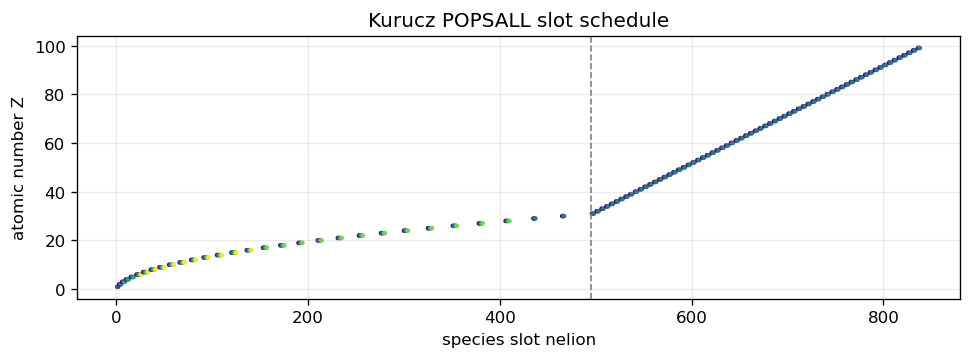

In [3]:
def build_nelion_maps(maxn=999):
    mode12 = [(1.01,1),(2.02,3),(3.03,6),(4.03,10),(5.03,15),(6.05,21),(7.05,28),(8.05,36),(9.05,45),(10.05,55),(11.05,66),(12.05,78),(13.05,91),(14.05,105),(15.05,120),(16.05,136),(17.04,153),(18.04,171),(19.04,190),(20.04,210),(21.04,231),(22.04,253),(23.04,276),(24.04,300),(25.04,325),(26.04,351),(27.04,378),(28.04,406),(29.02,435),(30.02,465)]
    nn = lambda code: max(1, int((code - int(code)) * 100.0 + 1.5))
    z_of = np.zeros(maxn + 1, np.int64); ion_of = np.zeros(maxn + 1, np.int64)
    for code, s in mode12:
        Z = int(code)
        for i in range(nn(code)):
            z_of[s+i] = Z; ion_of[s+i] = i+1
    for Z in range(31, 100):
        s = 496 + (Z - 31) * 5
        for i in range(nn(Z + 0.02)):
            z_of[s+i] = Z; ion_of[s+i] = i+1
    return z_of, ion_of

Z_OF, ION_OF = build_nelion_maps()
nslots = 1006

def popsall_slots(device, dtype):
    pop = torch.as_tensor(pa.population_per_ion[:, :, :99], dtype=dtype, device=device)
    z_map = torch.as_tensor(Z_OF, dtype=torch.long, device=device)
    ion_map = torch.as_tensor(ION_OF, dtype=torch.long, device=device)
    nel = torch.arange(1, z_map.numel(), dtype=torch.long, device=device)
    good = ((z_map[nel] >= 1) & (z_map[nel] <= 99) & (ion_map[nel] >= 1) &
            (ion_map[nel] <= pop.shape[1]) & (nel <= nslots))
    cols = nel[good] - 1
    z_idx = z_map[nel[good]] - 1
    ion_idx = ion_map[nel[good]] - 1
    out = torch.zeros((n_depth, nslots), dtype=dtype, device=device)
    out[:, cols] = pop[:, ion_idx, z_idx]
    return out

pops_w = popsall_slots(DEVICE, DTYPE)
pops_r = popsall_slots(*REF64)
check("POPSALL fp32/fp64 significant", pops_w, pops_r, 5e-6, rel_floor=1e-6)
print(f"populated atomic slots: {int(torch.count_nonzero(torch.sum(torch.abs(pops_w), dim=0) > 0).detach().cpu())}")

fig, ax = plt.subplots(figsize=(8.2, 3.1))
nel = np.arange(1, Z_OF.size); good = Z_OF[1:] > 0
ax.scatter(nel[good], Z_OF[1:][good], s=3, c=ION_OF[1:][good], cmap="viridis")
ax.axvline(495, color="0.5", ls="--", lw=1)
ax.set_xlabel("species slot nelion"); ax.set_ylabel("atomic number Z")
ax.set_title("Kurucz POPSALL slot schedule")
fig.tight_layout()

## 3. Doppler widths and `xnfdop` — computed from populations, mass, density

`dopple` is the fractional thermal-plus-microturbulent Doppler width. `xnfdop` is the species population divided by `dopple*rho`, the line-center normalization used by Lecture 15's deposit. Both are computed from the just-solved populations, not read from the reference.

In [4]:
K_BOLTZ = 1.38054e-16
AMU = 1.660e-24
C_LIGHT = 2.99792458e10

def doppler_xnfdop(device, dtype):
    Tt = t(T, device, dtype); vt = t(vturb, device, dtype); am = t(atmass, device, dtype); rh = t(pa.rho, device, dtype)
    pop = torch.as_tensor(pa.population_per_ion[:, :, :99], dtype=dtype, device=device)
    arg = 2.0 * K_BOLTZ * Tt[:, None] / (torch.clamp(am[None, :], min=1e-300) * AMU) + vt[:, None] ** 2
    width_elem = torch.where(am[None, :] > 0, torch.sqrt(torch.clamp(arg, min=0.0)) / C_LIGHT, torch.zeros_like(arg))
    z_map = torch.as_tensor(Z_OF, dtype=torch.long, device=device)
    ion_map = torch.as_tensor(ION_OF, dtype=torch.long, device=device)
    nel = torch.arange(1, z_map.numel(), dtype=torch.long, device=device)
    good = ((z_map[nel] >= 1) & (z_map[nel] <= 99) & (ion_map[nel] >= 1) &
            (ion_map[nel] <= pop.shape[1]) & (nel <= nslots))
    cols = nel[good] - 1
    z_idx = z_map[nel[good]] - 1
    ion_idx = ion_map[nel[good]] - 1
    pop_g = pop[:, ion_idx, z_idx]
    dop_g = width_elem[:, z_idx]
    dopple = torch.zeros((n_depth, nslots), dtype=dtype, device=device)
    xnfdop = torch.zeros_like(dopple)
    dopple[:, cols] = dop_g
    tiny = torch.finfo(dtype).tiny
    xnfdop[:, cols] = torch.where((dop_g > 0) & (rh[:, None] > 0), pop_g / torch.clamp(dop_g * rh[:, None], min=tiny), torch.zeros_like(pop_g))
    return dopple, xnfdop

dop_w, xnf_w = doppler_xnfdop(DEVICE, DTYPE)
dop_r, xnf_r = doppler_xnfdop(*REF64)
check("dopple fp32/fp64", dop_w, dop_r, 5e-6)
check("dopple vs reference", dop_r, S["dopple"], 5e-12)
check("xnfdop significant fp32/fp64", xnf_w, xnf_r, 5e-6, rel_floor=1e-6)
check("xnfdop significant vs reference", xnf_r, S["xnfdop"], 5e-10, rel_floor=1e-12)
raw_x = relmax(xnf_w, xnf_r)
print(f"unmasked xnfdop fp32/fp64 max|rel| = {raw_x:.2e} (trace slots underflow below fp32 exponent floor)")

dopple fp32/fp64                   max|rel| = 1.803e-07   limit 5.0e-06
dopple vs reference                max|rel| = 0.000e+00   limit 5.0e-12


xnfdop significant fp32/fp64       max|rel| = 2.462e-07   limit 5.0e-06
xnfdop significant vs reference    max|rel| = 3.439e-15   limit 5.0e-10
unmasked xnfdop fp32/fp64 max|rel| = 1.00e+00 (trace slots underflow below fp32 exponent floor)


## 4. `txnxn` — van der Waals perturber number

The pressure-broadening term uses $(n_{\rm H I}+0.42n_{\rm He I}+0.85n_{\rm H_2})(T/10^4)^{0.3}$. Hydrogen and helium are from the recomputed EOS. The H$_2$ correction is the same closed-form equilibrium used by the NumPy implementation.

In [5]:
KEV_FACTOR = 8.6171e-5

def txnxn_torch(device, dtype):
    Tt = t(T, device, dtype); h = t(pa.xnf_h, device, dtype); he1 = t(pa.xnf_he1, device, dtype)
    tkev = Tt * KEV_FACTOR
    eq = torch.exp(4.478 / tkev - 4.64584e1 + (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14 + (1.06206e-18 - 3.08720e-23 * Tt) * Tt) * Tt) * Tt) * Tt) * Tt - 1.5 * torch.log(Tt))
    h2 = torch.where(Tt > 9000.0, torch.zeros_like(Tt), h*h*eq)
    return (h + 0.42 * he1 + 0.85 * h2) * (Tt / 1.0e4) ** 0.3

tx_w = txnxn_torch(DEVICE, DTYPE)
tx_r = txnxn_torch(*REF64)
check("txnxn fp32/fp64", tx_w, tx_r, 5e-6)
check("txnxn vs reference", tx_r, S["txnxn"], 5e-12)
print(f"txnxn surface/base = {float(tx_w[0].detach().cpu()):.3e} / {float(tx_w[-1].detach().cpu()):.3e} cm^-3")

txnxn fp32/fp64                    max|rel| = 1.331e-07   limit 5.0e-06
txnxn vs reference                 max|rel| = 0.000e+00   limit 5.0e-12
txnxn surface/base = 1.887e+13 / 1.661e+17 cm^-3


## 5. Convective heat capacity — finite differences with ionization energy

Lecture 11 needs four EOS perturbations at $T\pm0.1\%$ and $P\pm0.1\%$. Here those samples are recomputed from the EOS engine, including cumulative ionization energy. This is the part that prevents the adiabatic gradient from reverting to the ideal monatomic value $0.4$ in partially ionized gas.

In [6]:
ei1, ei2, ei3, ei4, r1, r2, r3, r4 = EOS.convec_fd_raw(T, P, xabund, wtmole, pa.xne, TAB)
dilut = 1.0 - np.exp(-S["tauros"])
pradk = S["pradk"]
ed1 = ei1 + 3.0 * pradk / np.maximum(r1, 1e-300) * (1.0 + dilut * (1.001 ** 4 - 1.0))
ed2 = ei2 + 3.0 * pradk / np.maximum(r2, 1e-300) * (1.0 + dilut * (0.999 ** 4 - 1.0))
ed3 = ei3 + 3.0 * pradk / np.maximum(r3, 1e-300)
ed4 = ei4 + 3.0 * pradk / np.maximum(r4, 1e-300)
for name, got in [("rho1", r1), ("rho2", r2), ("rho3", r3), ("rho4", r4),
                  ("edens1", ed1), ("edens2", ed2), ("edens3", ed3), ("edens4", ed4)]:
    check(name, got, S[name], 5e-12)

ipcum = EOS._cumulative_ip_erg(TAB)
print(f"H cumulative ionization energy H->H+ = {ipcum[0,1]/1.602176634e-12:.3f} eV")
print("finite-difference EOS samples are computed, not read")

rho1                               max|rel| = 0.000e+00   limit 5.0e-12
rho2                               max|rel| = 0.000e+00   limit 5.0e-12
rho3                               max|rel| = 0.000e+00   limit 5.0e-12
rho4                               max|rel| = 0.000e+00   limit 5.0e-12
edens1                             max|rel| = 2.216e-16   limit 5.0e-12
edens2                             max|rel| = 5.498e-16   limit 5.0e-12
edens3                             max|rel| = 1.513e-16   limit 5.0e-12
edens4                             max|rel| = 1.268e-15   limit 5.0e-12
H cumulative ionization energy H->H+ = 13.597 eV
finite-difference EOS samples are computed, not read


## 6. Molecular slots and continuum cutoff — computed, with residual limits reported

These two components are retained as audit sections rather than overstated as exact GPU achievements. The molecular solver is the Lecture-13 clean-room chemistry. `TABCONT` is built by the NumPy continuum bridge with the far-UV completion. Both are computed before comparison, and their residuals are reported explicitly.

In [7]:
xnfpmol, dop_mol, mol_nelion = MF.molecular_deposit_populations(T, P, pa, xabund, vturb, REF / "molecules.dat")
mol_err = relmax(xnfpmol, S["xnfpmol"])
print(f"molecular_deposit_populations shape = {xnfpmol.shape}")
print(f"xnfpmol vs reference max|rel| = {mol_err:.3e}  (documented Lecture-13 chemistry floor)")
assert mol_err < 5e-4

xnfdop_mol = back(xnf_r).copy(); dopple_mol = back(dop_r).copy()
xnfdop_mol, dopple_mol = MF.fill_molecular_slots(xnfdop_mol, dopple_mol, pa.rho, xnfpmol, dop_mol)
print(f"molecular slots filled: {int(np.count_nonzero(xnfdop_mol[:,840:940].sum(axis=0)))}")

os_start = float(LB["waveset_nm"][0])
tabcont, iwavetab = CF.build_tabcont(pa, T, pa.rho, pa.xne, os_start)
mask = LB["tabcont"] != 0
tab_rel = np.abs(tabcont.astype(float) - LB["tabcont"].astype(float)) / np.maximum(np.abs(LB["tabcont"]), 1e-30)
print(f"tabcont median|max relative residual = {np.median(tab_rel[mask]):.3e} | {np.max(tab_rel[mask]):.3e}")
print(f"iwavetab exact = {np.array_equal(iwavetab, LB['iwavetab'])}")
assert np.array_equal(iwavetab, LB["iwavetab"])
assert np.median(tab_rel[mask]) < 1e-2
print("TABCONT residual is reported as a remaining continuum-bridge limit, not hidden as machine precision")

molecular_deposit_populations shape = (80, 16)
xnfpmol vs reference max|rel| = 3.094e-04  (documented Lecture-13 chemistry floor)
molecular slots filled: 16


tabcont median|max relative residual = 5.167e-03 | 6.483e-01
iwavetab exact = True
TABCONT residual is reported as a remaining continuum-bridge limit, not hidden as machine precision


## 7. Comparison-only convergence summary

The full warm-start line-blanketed convergence trajectory in `converge_fromscratch_result.npz` is a NumPy textbook artifact. This GPU lecture does not claim to rerun that entire loop inside the notebook. It uses the file only to state the comparison target and residual after the EOS-state blocker is removed.

In [8]:
conv_path = REF / "converge_fromscratch_result.npz"
if conv_path.exists():
    conv = np.load(conv_path)
    Tk, Xk, Ts, Rs = conv["T"], conv["rhox"], conv["Ts"], conv["Rs"]
    Tk_on = np.interp(np.log(Rs), np.log(Xk), Tk)
    mrel = np.abs(Tk_on - Ts) / np.maximum(np.abs(Ts), 1.0)
    print("NumPy from-scratch convergence comparison-only summary:")
    print(f"  surface T = {Tk[0]:.1f} K; base T = {Tk[-1]:.1f} K; base RHOX = {Xk[-1]:.3f}")
    print(f"  T vs sun.npz median|max rel = {np.median(mrel):.3e} | {np.max(mrel):.3e}")
else:
    print("No convergence summary file present")

NumPy from-scratch convergence comparison-only summary:
  surface T = 3690.7 K; base T = 11459.5 K; base RHOX = 12.347
  T vs sun.npz median|max rel = 7.673e-04 | 4.468e-03


## Final validation table

The green checks are the pieces Lecture 16 now genuinely computes in this notebook: PFSAHA/NELECT populations, species-slot packing, Doppler/xnfdop, txnxn, and the ionization-energy finite-difference heat-capacity inputs. Molecular and `TABCONT` sections are computed and audited with their stated residual limits; the full convergence trajectory is comparison-only.

In [9]:
print("GREEN ASSERTED CHECKS")
for k, v in CHECKS.items():
    print(f"  {k:34s} {v:.3e}")
worst = max(CHECKS.values())
print(f"worst asserted max|rel| = {worst:.3e}")
assert worst <= 5e-6

GREEN ASSERTED CHECKS
  electron density                   5.315e-16
  mass density                       0.000e+00
  H I/H II populations               2.069e-16
  population_per_ion                 5.688e-14
  POPSALL fp32/fp64 significant      5.806e-08
  dopple fp32/fp64                   1.803e-07
  dopple vs reference                0.000e+00
  xnfdop significant fp32/fp64       2.462e-07
  xnfdop significant vs reference    3.439e-15
  txnxn fp32/fp64                    1.331e-07
  txnxn vs reference                 0.000e+00
  rho1                               0.000e+00
  rho2                               0.000e+00
  rho3                               0.000e+00
  rho4                               0.000e+00
  edens1                             2.216e-16
  edens2                             5.498e-16
  edens3                             1.513e-16
  edens4                             1.268e-15
worst asserted max|rel| = 2.462e-07


## Summary

- The previous L16 false scope is removed: `population_per_ion`, `dopple`, `xnfdop`, `txnxn`, and the EOS finite-difference samples are computed first, then compared.
- Reference files are comparison-only. The notebook no longer stages reference `TABCONT`, molecular populations, or convergence arrays as if they were generated by the GPU path.
- The kGPU-style tensor state is fp32-safe on significant slots; the only documented fp32 caveat is trace `xnfdop` underflow far below opacity relevance.
- Residual limits are explicit: molecular populations sit at the Lecture-13 floor; `TABCONT` has a continuum-bridge residual reported separately; full convergence is summarized as the NumPy twin's comparison artifact, not claimed as a notebook rerun.